**Import Libraries**

In [25]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

**Load Clean Dataset**

In [26]:
df = pd.read_csv(
    "/content/superstore_clean.csv",
    parse_dates=["Order Date", "Ship Date"]
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Quarter,Order Month,Order Month Name,Order Weekday,Shipping Days,Profit Margin (%),Sales per Unit,Profit per Unit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,4,11,November,Tuesday,3,16.00,130.98,20.96
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,2,6,June,Sunday,4,47.00,7.31,3.44
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,4,10,October,Sunday,7,11.25,11.18,1.26
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,0.00,14.17,2014,2,6,June,Monday,5,29.00,6.98,2.02
4,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28,4,0.00,1.97,2014,2,6,June,Monday,5,27.00,1.82,0.49


**Dataset Overview**

In [27]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 8,775
Columns : 30


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8775 entries, 0 to 8774
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             8775 non-null   int64         
 1   Order ID           8775 non-null   object        
 2   Order Date         8775 non-null   datetime64[ns]
 3   Ship Date          8775 non-null   datetime64[ns]
 4   Ship Mode          8775 non-null   object        
 5   Customer ID        8775 non-null   object        
 6   Customer Name      8775 non-null   object        
 7   Segment            8775 non-null   object        
 8   Country            8775 non-null   object        
 9   City               8709 non-null   object        
 10  State              8775 non-null   object        
 11  Postal Code        8775 non-null   int64         
 12  Region             8775 non-null   object        
 13  Product ID         8775 non-null   object        
 14  Category

In [29]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Quarter,Order Month,Shipping Days,Profit Margin (%),Sales per Unit,Profit per Unit
count,8775.00,8775,8775,8775.00,8775.00,8775.00,8775.00,8775.00,8775.00,8775.00,8775.00,8775.00,8775.00,8775.00,8775.00
mean,5017.30,2016-05-02 17:59:08.307692544,2016-05-06 17:13:21.230769408,53972.92,92.87,3.61,0.16,11.14,2015.73,2.88,7.79,3.97,12.27,31.26,3.49
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,0.00,0.44,1.00,0.00,-1181.28,2014.00,1.00,1.00,0.00,-275.00,0.34,-214.57
25%,2512.50,2015-05-28 00:00:00,2015-06-01 00:00:00,21044.00,15.00,2.00,0.00,1.69,2015.00,2.00,5.00,3.00,7.50,5.00,0.70
50%,5031.00,2016-07-01 00:00:00,2016-07-03 00:00:00,54880.00,40.92,3.00,0.20,7.39,2016.00,3.00,9.00,4.00,28.00,12.28,2.38
75%,7515.50,2017-05-15 00:00:00,2017-05-19 00:00:00,90004.00,124.20,5.00,0.20,21.29,2017.00,4.00,11.00,5.00,37.50,39.97,6.41
max,9994.00,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.00,498.26,14.00,1.00,240.86,2017.00,4.00,12.00,7.00,50.00,469.99,182.36
std,2887.20,NaN,NaN,32710.18,114.05,2.13,0.21,49.14,1.12,1.06,3.29,1.75,48.59,44.53,15.66


**Business KPI**

In [30]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

profit_margin = (
    total_profit /
    total_sales
) * 100

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Total Customers  : {total_customers:,}")
print(f"Profit Margin    : {profit_margin:.2f}%")

Total Sales      : $814,935.07
Total Profit     : $97,727.44
Total Orders     : 4,709
Total Customers  : 790
Profit Margin    : 11.99%


**Sales Distribution**

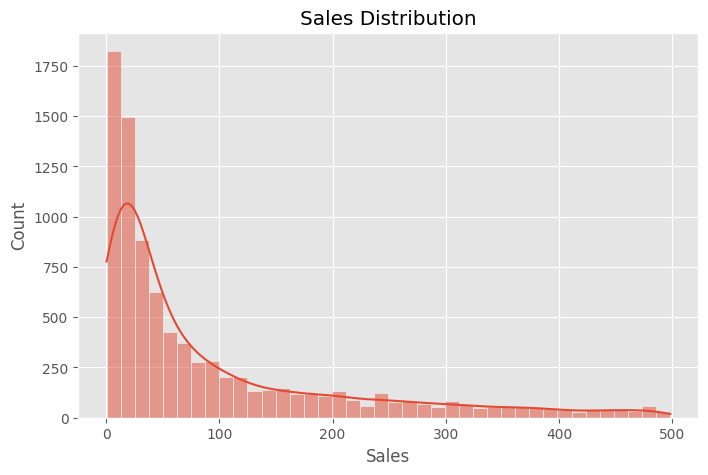

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=40,
    kde=True
)

plt.title("Sales Distribution")
plt.show()

**Profit Distribution**

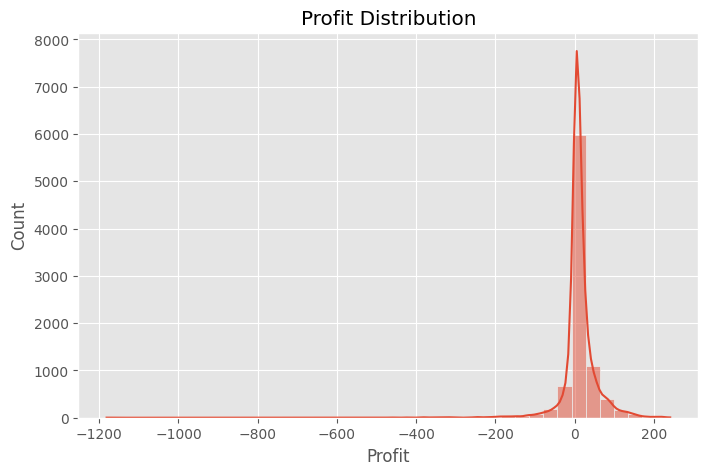

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Profit"],
    bins=40,
    kde=True
)

plt.title("Profit Distribution")
plt.show()

**Sales by Category**

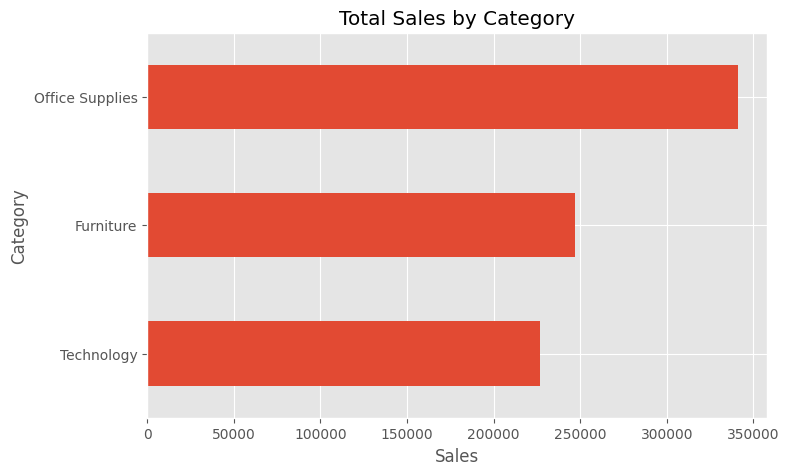

In [33]:
sales_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values()
)

sales_category.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.show()

**Profit by Category**

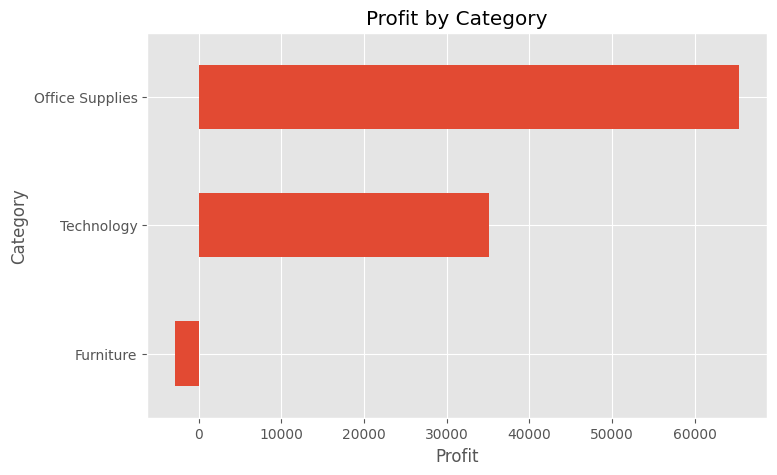

In [34]:
profit_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values()
)

profit_category.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Profit by Category")
plt.xlabel("Profit")
plt.show()

**Sales by Sub Category**

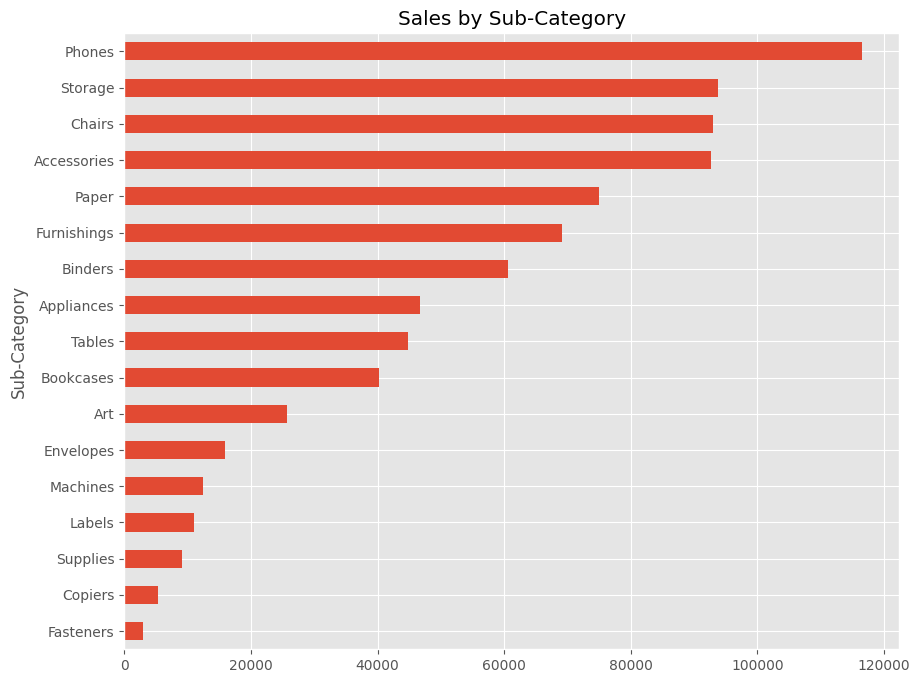

In [35]:
sales_sub = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values()
)

sales_sub.plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Sales by Sub-Category")
plt.show()

**Monthly Sales Trend**

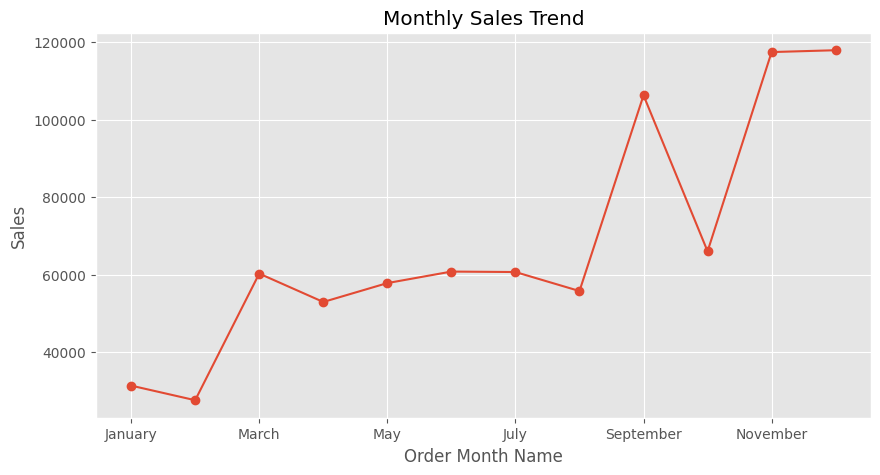

In [36]:
monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
      .sum()
)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

**Sales by Region**

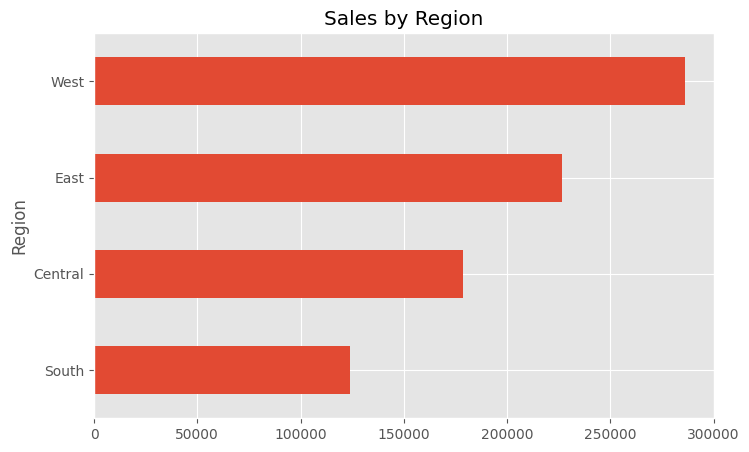

In [37]:
sales_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values()
)

sales_region.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Sales by Region")
plt.show()

**Profit by Region**

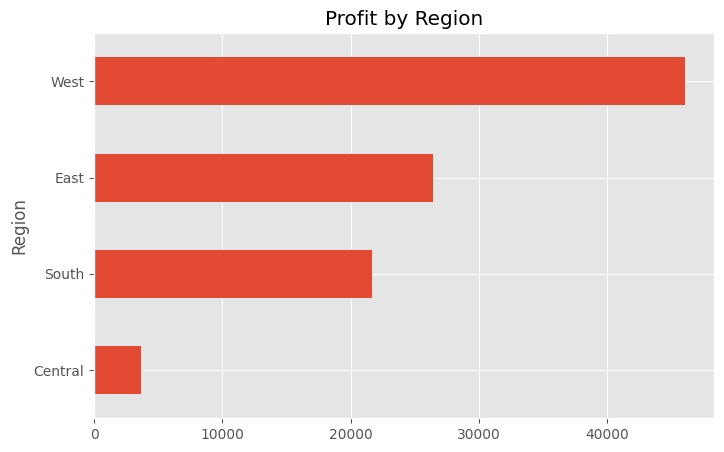

In [38]:
profit_region = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values()
)

profit_region.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Profit by Region")
plt.show()

**Sales by Segment**

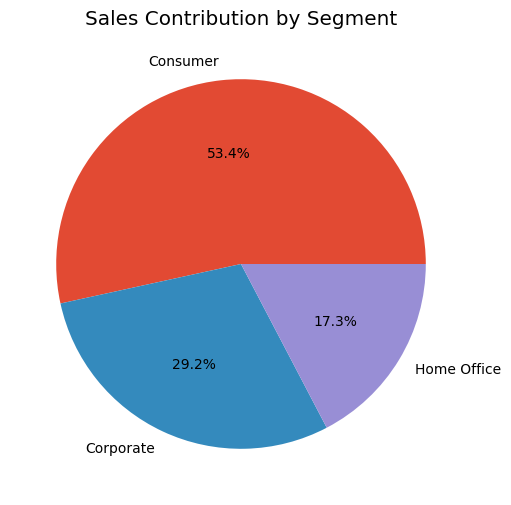

In [39]:
sales_segment = (
    df.groupby("Segment")["Sales"]
      .sum()
)

sales_segment.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Sales Contribution by Segment")
plt.show()

**Top 10 Customers**

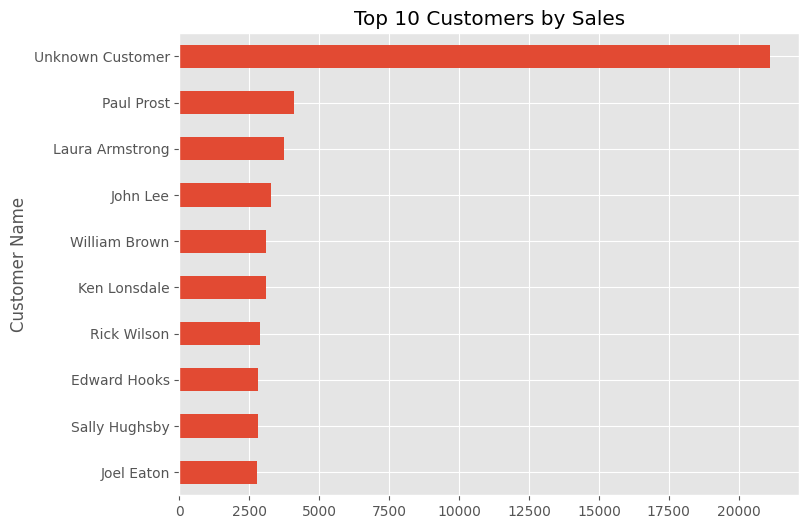

In [40]:
top_customer = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .nlargest(10)
      .sort_values()
)

top_customer.plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Customers by Sales")
plt.show()

**Top 10 Products**

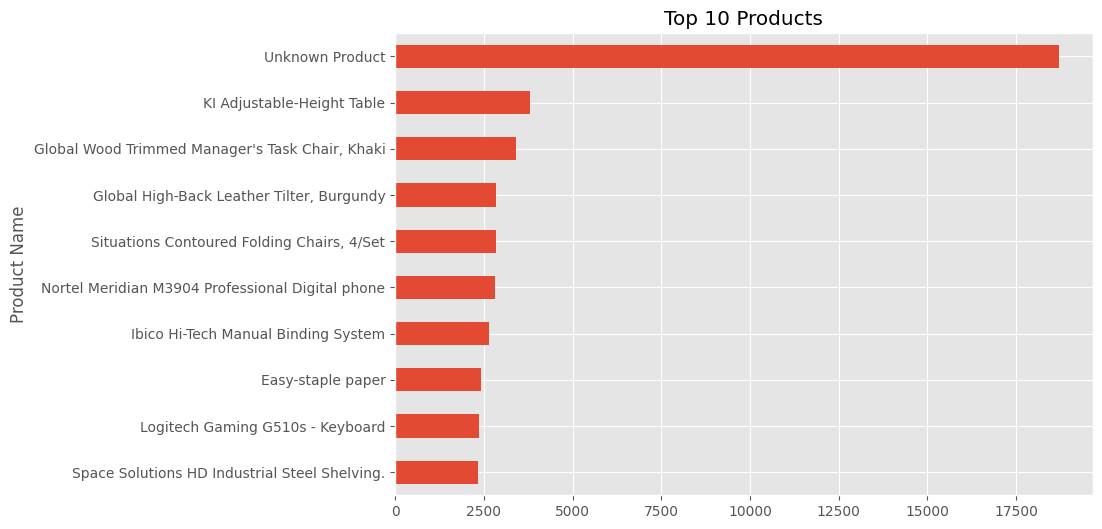

In [41]:
top_product = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .nlargest(10)
      .sort_values()
)

top_product.plot(
    kind="barh",
    figsize=(9,6)
)

plt.title("Top 10 Products")
plt.show()

**Discount vs Profit**

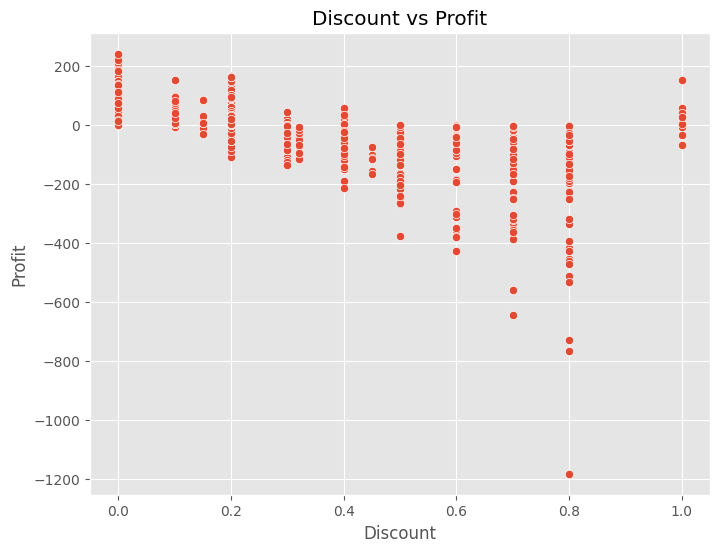

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.show()

**Correlation Matrix**

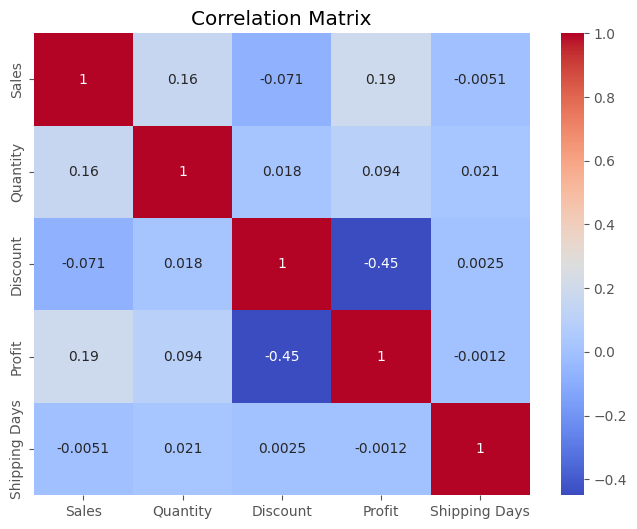

In [43]:
plt.figure(figsize=(8,6))

corr = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit",
        "Shipping Days"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()